# CODEX Generation

### Imports (run first)

In [1]:
import pandas as pd
import os
import warnings

os.chdir('/home/LULAB/wboohar/CODEX/data_processing/code')
from codex_project import codex_project, replace_marker_match_centroids, read_marker_combos, get_marker_list
warnings.filterwarnings('ignore')

### Parameters
annotations_path  
> .json annotations list

base_dir  
> location of base directory, should include raw_data folder w/ project folders inside

project_name
> name of project, will create a folder with this name in the base directory

project_folders
> list of folders with marker data inside to be used for this project (names of folders are not used)

sample_labels
> dict relating project_folders names to a label, will be in 'Parent' column (typically this is used to show mouse information)

In [2]:
annotations_path = '/store/Projects/wboohar/PhenoCycler/annotation_strategies/marker_combos_062525_updated_verified.json.json'   
base_dir = '/store/Projects/wboohar/PhenoCycler' 
project_name = 'QuantCellPaper'
project_path = f'{base_dir}/{project_name}'
data_path = f'{base_dir}/raw_data'

project_folders = ['122123BW Annotations']
# sample ages in file are correct

sample_labels = {'122123BW Annotations':'QuantCellPaper'}


project_folders_replace = ['012925BW Y1 Annotations', '012925BW Y3 Annoations', '013025BW O1 Annotations', '013125BW O2 Annotations', '013125BW O3 Annotation', '020425BW Y2 Annotations']
sample_labels_replace = {
    '012925BW Y1 Annotations' : 'Y1',
    '012925BW Y3 Annoations' : 'Y3',
    '013025BW O1 Annotations' : 'O1',
    '013125BW O2 Annotations' : 'O2',
    '013125BW O3 Annotation' : 'O3',
    '020425BW Y2 Annotations' : 'Y2'
}

In [4]:
os.makedirs(project_path, exist_ok=True)

codex = codex_project()
codex.initialize(data_path=data_path, folders=project_folders, project_name=project_name, annotation_strategy_path=annotations_path)
codex.set_sample_labels(sample_labels)

In [5]:
if 'project_folders_replace' in globals():
    replace_codex = codex_project()
    replace_codex.initialize(data_path=data_path, folders=project_folders_replace, project_name=project_name, annotation_strategy_path=annotations_path)
    replace_codex.set_sample_labels(sample_labels_replace)
    for marker in ['CD45', 'Ter119', 'CD41']:
        codex.codex = replace_marker_match_centroids(codex.codex, replace_codex.codex, marker)
   # del replace_codex

In [6]:
codex.annotate()
codex.drop_missing(max_missing_per_col=1000000)

OLD DIMENSIONS: (262271, 548)
NEW DIMENSIONS: (245719, 548)


In [7]:
codex.verify_marker_annotations()

~~~Verifying markers in /store/Projects/wboohar/PhenoCycler/raw_data/122123BW Annotations~~~
Missing markers: []
Unused markers: ['CD21_35', 'CD38', 'CD44', 'CD48', 'CD49f', 'CD5', 'CD90', 'Flk2', 'Foxp3', 'IgD', 'Ki67']



True

In [8]:
assert(len(codex.codex.loc[:, 'cell_type'].unique()) == len(codex._marker_combos.keys())+1)

In [9]:
codex.section_samples(eps=500)

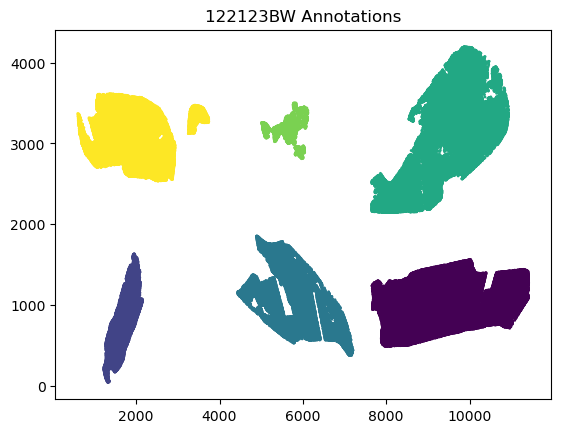

In [10]:
#codex.override_sectioning() # replace all sections with the name of the data folder + _0, use for IF images
codex.visualize_sectioning()

In [11]:
codex.verify_sectioning()

~~~Verifying sectioning~~~
Passed: All cells assigned in 122123BW Annotations


In [12]:
codex.save_csv(f'{project_path}/codex_conventional_{project_name}.csv')

# Load in
Includes all data except the folders in which the raw data is

In [ ]:
codex = codex_project()
codex.read_csv(f'{project_path}/codex_conventional_{project_name}.csv', project_name=project_name)
codex.read_annotation_strategy(annotations_path)

In [ ]:
codex.codex.cell_type.value_counts()/len(codex.codex)

In [ ]:
for s in codex.codex.section.unique():
    mask = codex.codex.section == s
    print(s)
    counts = codex.codex[mask].cell_type.value_counts()
    print('Count \tPercent Cell Type')
    for ct in sorted(counts.index):
        print(f'{counts[ct]} \t{counts[ct]/counts.sum()*100:.2f}%\t{ct}')

    print()